# St. Louis Tree Canopy & Income Equity Analysis

This notebook analyzes the relationship between median household income and tree canopy coverage across census tracts in St. Louis City, Missouri. The goal is to identify **priority zones** (tracts with both low income and low canopy coverage) to help guide community-led planting initiatives.

St. Louis is one of the most well-documented examples of redlining in the US. Because trees take decades to grow, neighborhoods that experienced systematic disinvestment in the mid-20th century often still show lower canopy coverage today. This analysis asks whether that pattern is visible in current data.

## 1. Environment Setup

Import all required libraries and load environment variables. The NHGIS API key is stored as an environment variable (`IPUMS_API_KEY`) rather than hardcoded for security. Reference Conda documentation for more information

In [220]:
# Import statements and environment variables
from ipumspy import AggregateDataExtract, NhgisDataset, IpumsApiClient
from rasterio.mask import mask as geom_mask
from rasterio.plot import show
from scipy.stats import spearmanr
from shapely.geometry import mapping
from rasterstats import zonal_stats
import zipfile
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import os 
import pandas as pd
import pygris
import numpy as np

IPUMS_API_KEY = os.getenv('IPUMS_API_KEY') # Need to configure IPUMS API KEY in environmental variables prior to running
ipums = IpumsApiClient(IPUMS_API_KEY)

#Create data/raw directories
target_dir = os.path.join("data", "raw")
os.makedirs(target_dir, exist_ok=True)
pd.options.display.float_format = '{:.2f}'.format

## 2. Fetch Census Tract Data via NHGIS API

We use `ipumspy` to pull tract-level median household income (ACS Table B19013) for St. Louis City, Missouri.

**Geographic identifiers:**
- State FIPS: `29` (Missouri). Using '290' for the API
- County FIPS: `510` (St. Louis City — a county-equivalent independent city, separate from St. Louis County which is FIPS 189)

**Dataset:** `2020_2024_ACS5a` (2020–2024 ACS 5-Year Estimates, Block Groups & Larger Areas)

The extract is submitted programmatically so this analysis is fully reproducible. Free account creation is required.

In [ ]:
# NHGIS dataset parameters
dataset = NhgisDataset(
    name="2020_2024_ACS5a",
    data_tables=["B19013"],
    geog_levels=["tract"]
)
# IPUMS Extract parameters, including NHGIS dataset params
extract = AggregateDataExtract(
    collection="nhgis",
    description="2024 Median Household Income by Census Tract for Missouri", 
    datasets=[dataset],
    geographic_extents=['290']
    )

# Submitting and downloading the extract
ipums.submit_extract(extract)
print("Extract submitted to IPUMS.")
ipums.wait_for_extract(extract)
print("Please wait. Extract download in progress...")
ipums.download_extract(extract, download_dir=target_dir)
print(f"Extract completed! ZIP file(s) saved to {target_dir}")


In [2]:
# Extract data from zip file
zip_path = r"data\raw\nhgis0004_csv.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(target_dir)
    print(f"Unzipped files to: {target_dir}")

csv_path = r"data\raw\nhgis0004_csv\nhgis0004_ds272_20245_tract.csv"


Unzipped files to: data\raw


In [3]:
census_df = pd.read_csv(csv_path)

## 3. Load and Filter Census Tract Geometries

Use 'pygris' library to pull census tract boundaries from US Census bureau's website. Loads into gdf automatically.

For any area calculations we reproject to a metric CRS. Missouri State Plane East (EPSG 26996) is appropriate for St. Louis.

Using FIPS code '29' for input 'MO'
Using FIPS code '510' for input 'St. Louis City'
The CRS is: EPSG:4269
There are 104 tracts in this dataset


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,29,510,123200,29510123200,1232,Census Tract 1232,G5020,S,1113329,0,+38.6132904,-090.2137501,"POLYGON ((-90.22163 38.6116, -90.22153 38.6120..."
1,29,510,124600,29510124600,1246,Census Tract 1246,G5020,S,2152098,578571,+38.5890298,-090.2141395,"POLYGON ((-90.22765 38.58271, -90.22753 38.583..."
2,29,510,125500,29510125500,1255,Census Tract 1255,G5020,S,1099352,0,+38.6293098,-090.2029461,"POLYGON ((-90.21128 38.62764, -90.21126 38.627..."
165,29,510,104500,29510104500,1045,Census Tract 1045,G5020,S,1939714,0,+38.6265570,-090.2808684,"POLYGON ((-90.29432 38.62098, -90.29425 38.621..."
166,29,510,106100,29510106100,1061,Census Tract 1061,G5020,S,962329,0,+38.6693968,-090.2811551,"POLYGON ((-90.29005 38.67058, -90.28941 38.671..."


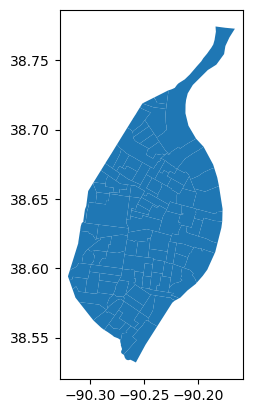

In [ ]:
# Pulling St. Louis, Missouri Census Tract boundaries using pygris
stl_tracts = pygris.tracts(state = "MO", county = "St. Louis City", year=2020)

# Preliminary Data checks
stl_tracts.plot() # For visual verification
print(f"The CRS is: {stl_tracts.crs}")
print(f"There are {len(stl_tracts)} tracts in this dataset")
stl_tracts.head()

The code below was a response due to the differing data types in the columns I was going to use to join the gdf and df together with.

In [ ]:
# Convert 'TL_GEO_ID' from INT to STR in order to join the data
census_df['TL_GEO_ID'] = census_df['TL_GEO_ID'].astype(str)

# Confirm both fields are of type 'object' or str prior to merge/join
print(census_df.dtypes['TL_GEO_ID'])
print(stl_tracts.dtypes['GEOID'])

object
object


Performed an inner join between the tracts gdf and the census df using the 'GEOID' and 'TL_GEO_ID' fields. Did some cleanup on blank, redundant or unnecessary fields.

In [ ]:
# Merging STL Tracts to Census data
stl_tracts_merged = stl_tracts.merge(census_df, left_on='GEOID', right_on='TL_GEO_ID', how='inner')

# Renamed coded median income field to 'median_income'
stl_tracts_merged = stl_tracts_merged.rename(columns = {'AURUE001': 'median_income'})

# Remove blank and unnecessary columns
stl_tracts_merged = stl_tracts_merged.drop(columns=[
    # NHGIS contextual columns
    'NAME_M', 'AURUM001', 'BTTRA', 'BTBGA', 'BLKGRPA', 'CONCITA',
    'AIANHHA', 'RES_ONLYA', 'TRUSTA', 'AIHHTLI', 'AITSA', 'ANRCA',
    'CBSAA', 'CSAA', 'METDIVA', 'UAA', 'CDCURRA', 'SLDUA', 'SLDLA',
    'ZCTA5A', 'SUBMCDA', 'SDELMA', 'SDSECA', 'SDUNIA', 'PCI', 'PUMAA',
    'REGIONA', 'DIVISIONA', 'COUNTYA', 'COUSUBA', 'PLACEA', 'GISJOIN',
    'STATEA', 'TRACTA', 'GEO_ID','TL_GEO_ID','STATE','COUNTY','YEAR',
    'NAMELSAD', 'NAME_E', 'STUSAB',
    # TIGER/Line administrative columns
    'TRACTCE', 'MTFCC', 'FUNCSTAT'
])

## 4. Load and Clip NLCD Tree Canopy Raster

The NLCD tree canopy cover raster is a national dataset at 30-meter resolution. To save memory and processing time, I clipped it to the bounding box of the St. Louis City tracts before doing anything else.

Do **not** reproject the raster. Reprojecting a raster requires resampling pixel values and introduces distortion. Instead, we let `rasterstats` handle CRS alignment internally during the zonal statistics step, keeping our pixel values untouched.

In [244]:
# Raster load and clip to bounding box goes here
nlcd_raster_raw = r'data\raw\NLCD_44d6a22a-40bc-4e66-b81b-ae412170fde0\nlcd_tcc_conus_wgs84_v2023-5_20230101_20231231_44d6a22a-40bc-4e66-b81b-ae412170fde0.tiff'

with rasterio.open(nlcd_raster_raw) as src:
    
    #1. Find CRS
    raster_crs = src.crs

    #2. Find the pixel data type
    raster_dtype = src.dtypes[0]

    #3. Find the nodata value
    raster_nodata = src.nodata

    #4. Find raster shape and bounds
    raster_shape = src.shape
    raster_bounds = src.bounds

    print(f"CRS: {raster_crs}")
    print(f"Data Type: {raster_dtype}")
    print(f"NoData Value: {raster_nodata}")
    print(f"Shape: {raster_shape}")
    print(f"Bounds: {raster_bounds}")

    # Reproject tract geometries to that of the raster
    stl_tracts_albers = stl_tracts_merged.to_crs(src.crs)
    print("New CRS of tracts geometries is: ", stl_tracts_albers.crs)


# Get the geometry shapes needed for geom_mask
shapes = [mapping(geom) for geom in stl_tracts_albers.geometry]

# Open raster, and clip to the bounding box of reprojected tracts
with rasterio.open(nlcd_raster_raw) as src:
    clipped_array, clipped_transform = geom_mask(dataset=src, shapes=shapes, nodata=255, crop=True)
    metadata = src.meta.copy()

# Update metadata with new shape and transform
metadata.update({
    "height": clipped_array.shape[1],
    "width": clipped_array.shape[2],
    "transform": clipped_transform,
    "nodata": 255
})
 
# Save clipped raster
output_path =  r'data\raw\clipped_stl_nlcd.tiff'
with rasterio.open(output_path, 'w', **metadata) as dst:
    dst.write(clipped_array)


CRS: PROJCS["Albers_Conical_Equal_Area",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Data Type: uint8
NoData Value: 255.0
Shape: (954, 542)
Bounds: BoundingBox(left=487785.0, bottom=1736625.0, right=504045.0, top=1765245.0)
New CRS of tracts geometries is:  PROJCS["Albers_Conical_Equal_Area",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY

## 5. Zonal Statistics

Calculate the mean tree canopy percentage for each census tract polygon using `rasterstats`.

**Key parameter:** `all_touched=False` - only pixels whose center falls within a tract boundary are included. Setting this to `True` would pull in boundary-straddling pixels, which in a dense urban environment with small tracts could systematically bias canopy estimates by including road and highway pixels along every tract edge.

In [245]:
# Zonal statistics
stl_zonal = zonal_stats(stl_tracts_albers,output_path,stats=['mean','count'], all_touched=False, nodata=255)

## 6. Merge and Clean

Merge the zonal statistics output with the Census income GeoDataFrame on the tract identifier. Check for nulls and any unexpected values before proceeding.

During step 7, it was discovered that there was a value in the 'median_income' field of -666,666,666, which is a coded entry for having not enough samples. Therefore 1 census tract was removed from the data for not having a valid median income. 

In [246]:
# Merge and null check goes here
stl_zonal_df = pd.DataFrame(stl_zonal)
stl_zonal_df = stl_zonal_df.rename(columns={'mean':'canopy_pct','count':'pixel_count'})
stl_zonal_df_join = stl_zonal_df.join(stl_tracts_merged)
stl_zonal_df_join.head()

# Remove -666,666,666 values from zonal df
stl_zonal_df_join = stl_zonal_df_join[stl_zonal_df_join['median_income'] > 0]
stl_zonal_df_join.shape

KeyError: 'median_income'

## 7. Exploratory Data Analysis

Before setting any thresholds, we examine the distributions of both variables and check whether a relationship between income and canopy actually exists in this data.

Steps:
- Summary statistics (min, max, mean, median) for both income and canopy
- Skewness of canopy_pct and median_income
- Histogram of each variable to check distribution shape
- Scatterplot of income vs canopy (one point per tract)
- Spearman correlation coefficient

**Why Spearman?** Income distributions in urban areas tend to be right-skewed. Spearman's rank-based approach is more robust to skew and outliers than Pearson correlation.

       canopy_pct  pixel_count       ALAND     AWATER  median_income
count      103.00       103.00      103.00     103.00         103.00
mean        11.59      1841.81  1545379.89  112264.16       54462.83
std          5.19      1866.87  1261722.81  515438.34       23728.02
min          0.90       564.00   506376.00       0.00       14719.00
25%          8.33      1042.00   938407.00       0.00       38495.50
50%         11.71      1273.00  1146088.00       0.00       50703.00
75%         15.20      1940.50  1720636.00       0.00       73484.50
max         25.59     16896.00 10287339.00 4918428.00      127772.00 

Skewness of canopy_pct : 0.13124303643061597 

Skewness of median_income : 0.484297296851193




array([[<Axes: title={'center': 'median_income'}>]], dtype=object)

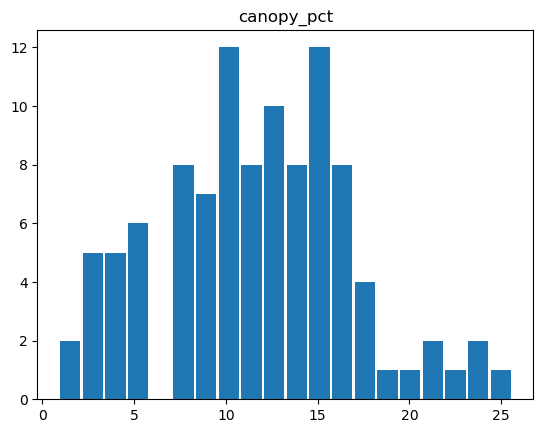

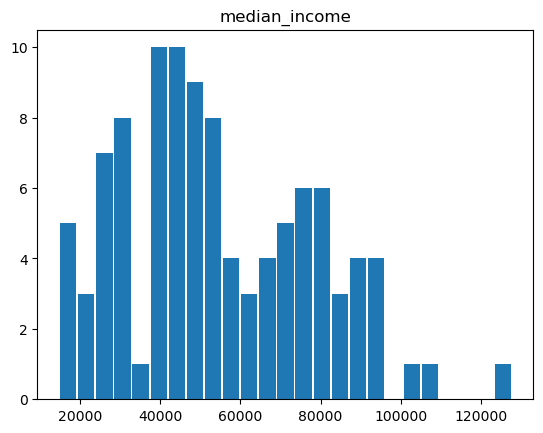

In [90]:
# EDA goes here
# General summary statistics, including skewness
print(stl_zonal_df_join.describe(),"\n")
print("Skewness of canopy_pct :", stl_zonal_df_join['canopy_pct'].skew(),"\n")
print("Skewness of median_income :", stl_zonal_df_join['median_income'].skew())

# Histogram and skewness of canopy_pct
stl_zonal_df_join.hist(column='canopy_pct',rwidth=.9,grid=False, bins=20)
print("\n")
stl_zonal_df_join.hist(column='median_income',rwidth=.9,grid=False, bins=25)


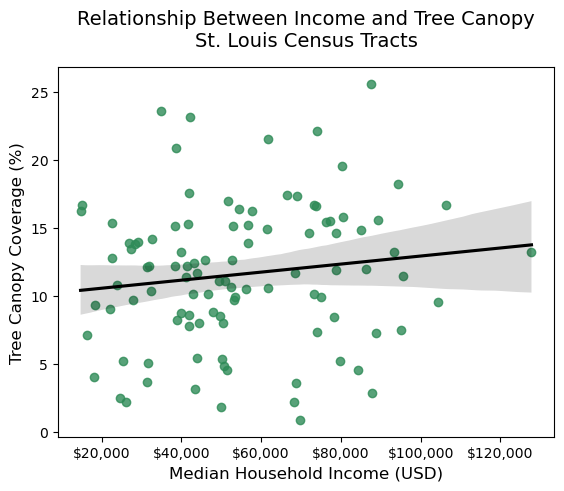

In [ ]:
# Create regression plog in Seaborn
sns.regplot(data=stl_zonal_df_join, x='median_income', y='canopy_pct', line_kws={'color':'black'}, color="seagreen")

# Add Titles and Labels
plt.title('Relationship Between Income and Tree Canopy\nSt. Louis City Census Tracts', fontsize=14, pad=15)
plt.xlabel('Median Household Income (USD)', fontsize=12)
plt.ylabel('Tree Canopy Coverage (%)', fontsize=12)

# Improve the look of the axis numbers (adding commas to income)
from matplotlib.ticker import StrMethodFormatter
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.show()

In [114]:
# Calculate Spearman R
# Correlation and p-value
coef, p_value = spearmanr(stl_zonal_df_join['median_income'], stl_zonal_df_join['canopy_pct'])

print(f"Spearman Correlation Coefficient: {coef:.3f}")
print(f"p-value: {p_value:.5f}")

Spearman Correlation Coefficient: 0.137
p-value: 0.16692


## 8. Classify Priority Zones

Based on the exploratory analysis above, set thresholds for low income and low canopy. Apply binary flags (1 = meets threshold, 0 = does not) to each tract for both variables. Priority zones are tracts where both flags equal 1.

Thresholds are documented here with the reasoning behind them.

In [125]:
# Create two binary flag columns, and overlap column. Fill with '0' data to start out with.
stl_zonal_df_join['low_canopy_flag'] = 0
stl_zonal_df_join['low_income_flag'] = 0
stl_zonal_df_join['priority_zone'] = 0

# Classification and priority zone flagging goes here
stl_zonal_df_join['low_canopy_flag'] = np.where(stl_zonal_df_join['canopy_pct'] < 6.45, 1, 0)
stl_zonal_df_join['low_income_flag'] = np.where(stl_zonal_df_join['median_income'] < 30735, 1, 0)
stl_zonal_df_join['priority_zone'] = np.where(((stl_zonal_df_join['low_canopy_flag'] == 1) & stl_zonal_df_join['low_income_flag'] == 1), 1, 0)
stl_zonal_df_join.head()

# Find how many tracts are 'priority zones'
print(stl_zonal_df_join['low_canopy_flag'].value_counts())
print(stl_zonal_df_join['low_income_flag'].value_counts())
print(stl_zonal_df_join['priority_zone'].value_counts())


low_canopy_flag
0    85
1    18
Name: count, dtype: int64
low_income_flag
0    86
1    17
Name: count, dtype: int64
priority_zone
0    99
1     4
Name: count, dtype: int64


## 9. Visualization

Map the priority zones alongside income and canopy distributions. Export the final GeoDataFrame as a GeoJSON for sharing or further visualization in QGIS or Leafmap.

In [205]:
# Map columns with labels for binary (0/1) outcomes
stl_zonal_df_join['low_canopy_label'] = stl_zonal_df_join['low_canopy_flag'].map({0: 'Average/High Canopy', 1: 'Low Canopy'})
stl_zonal_df_join['low_income_label'] = stl_zonal_df_join['low_income_flag'].map({0: 'Average/High Income', 1: 'Low Income'})
stl_zonal_df_join['priority_z_label'] = stl_zonal_df_join['priority_zone'].map({0: 'Non-priority Zone', 1: 'Priority Zone'})

# Use numpy.select for the combined categorical map column
conditions = [(stl_zonal_df_join['low_income_flag'] == 1) & (stl_zonal_df_join['low_canopy_flag'] == 1),
    (stl_zonal_df_join['low_income_flag'] == 1) & (stl_zonal_df_join['low_canopy_flag'] == 0),
    (stl_zonal_df_join['low_income_flag'] == 0) & (stl_zonal_df_join['low_canopy_flag'] == 1),
    (stl_zonal_df_join['low_income_flag'] == 0) & (stl_zonal_df_join['low_canopy_flag'] == 0)]
choices = ["Priority Zone", "Low Income Only", "Low Canopy Only", "Neither"]
stl_zonal_df_join['zone_category'] = np.select(conditions, choices, default='Neither')

# Convert to gdf
stl_zonal_df_join = gpd.GeoDataFrame(stl_zonal_df_join, geometry='geometry', crs=stl_tracts_merged.crs)

The below maps show median houshold income (2020-2024), 

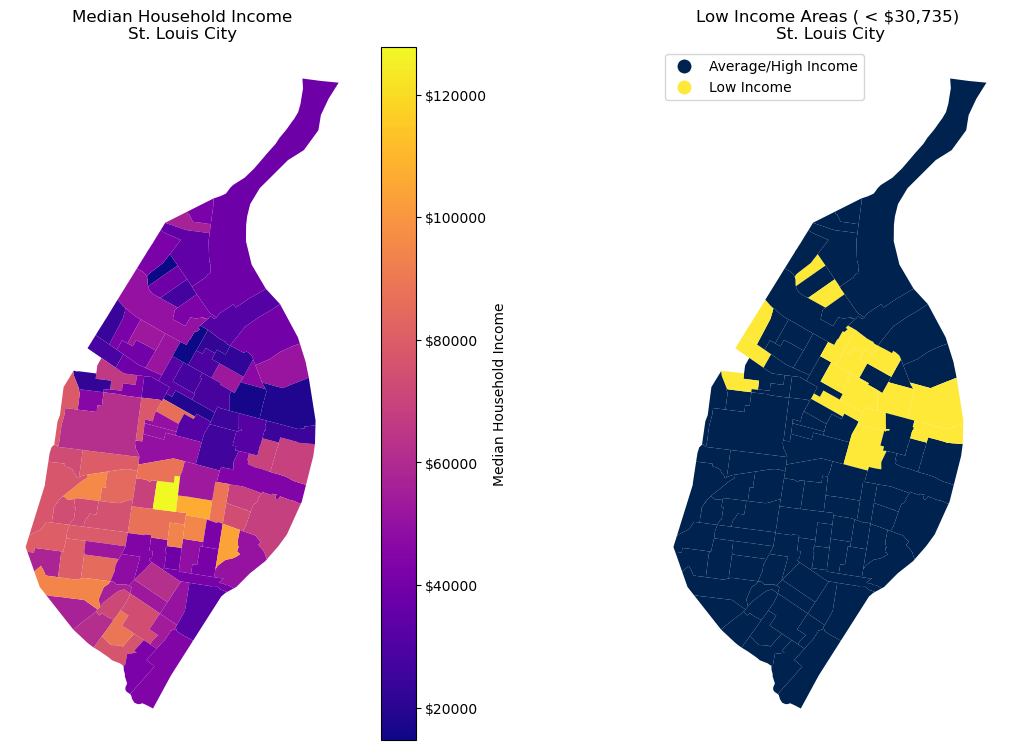

In [ ]:
# Visualization and export goes here

# Median Household Income
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 9))
stl_zonal_df_join.plot(column='median_income', ax=ax1, legend=True, cmap="plasma",legend_kwds={"label":"Median Household Income",'format':"$%.0f"})
ax1.set_title("Median Household Income\nSt. Louis City")
stl_zonal_df_join.plot(column='low_income_label', ax=ax2, legend=True, cmap="cividis",categorical=True, legend_kwds={'loc':'upper left'})
ax2.set_title("Low Income Areas ( < $30,735) \nSt. Louis City")

# Remove lat/long axes and ticks
ax1.axis('off')
ax2.axis('off')


plt.savefig(r'figures/median_income_stl.png',dpi=200)
plt.show()

MARKDOWN ABOUT CANOPY MAPS

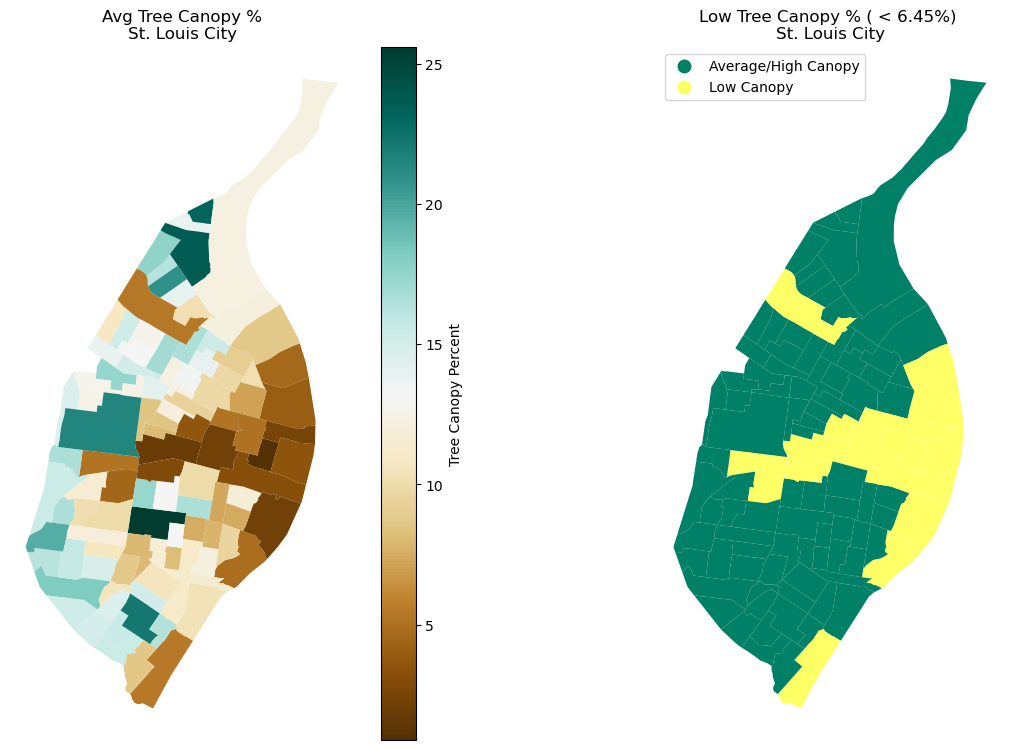

In [232]:
# Canopy Cover
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 9))
stl_zonal_df_join.plot(column='canopy_pct', ax=ax3, legend=True, cmap="BrBG",legend_kwds={"label":"Tree Canopy Percent"})
ax3.set_title("Avg Tree Canopy %\nSt. Louis City")
stl_zonal_df_join.plot(column='low_canopy_label', ax=ax4, legend=True, cmap="summer",categorical=True, legend_kwds={'loc':'upper left'})
ax4.set_title("Low Tree Canopy % ( < 6.45%) \nSt. Louis City")

# Remove lat/long axes and ticks
ax3.axis('off')
ax4.axis('off')

plt.savefig(r'figures/avg_tree_canopy_stl.png',dpi=200)
plt.show()

MARKDOWN ABOUT COMBINED CATEGORICAL MAP

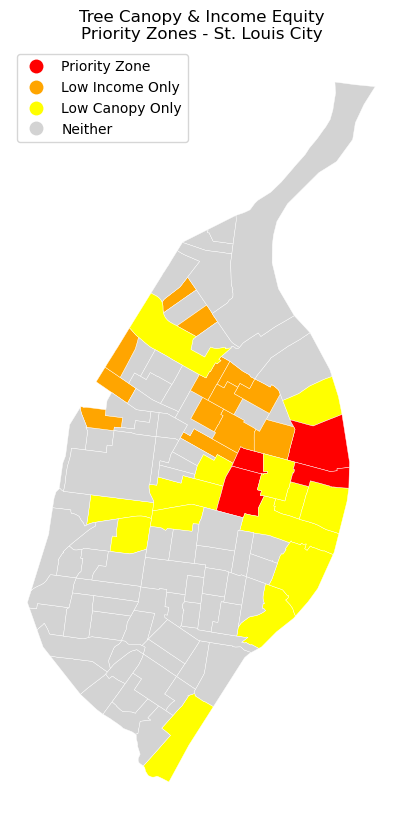

In [233]:
# Standalone Categorial Map
# Ensure the dataframe is Categorical and ordered
categories = ["Priority Zone", "Low Income Only", "Low Canopy Only", "Neither"]
stl_zonal_df_join['zone_category'] = stl_zonal_df_join['zone_category'].astype(
    pd.CategoricalDtype(categories=categories, ordered=True))

# Create a colormap from your list of colors (must match the order above)
custom_cmap = mcolors.ListedColormap(['red', 'orange', 'yellow', 'lightgray'])

fig, ax = plt.subplots(figsize=(10,10))
stl_zonal_df_join.plot(column='zone_category', ax=ax, legend=True, cmap=custom_cmap, categorical=True, edgecolor='white', linewidth=0.3, legend_kwds={'loc':'upper left'})
ax.set_title("Tree Canopy & Income Equity\nPriority Zones - St. Louis City")

# Remove lat/long axes and ticks
ax.axis('off')

plt.savefig(r'figures/combined_categorical_income_tree_stl.png',dpi=200)
plt.show()

In [ ]:
# Export final gdf to geojson for later analysis in QGIS or Leafmap
final_columns = ['canopy_pct', 'pixel_count', 'GEOID', 'NAME',  'ALAND', 'AWATER', 'geometry', 'median_income','low_canopy_label', 'low_income_label', 'priority_z_label', 'zone_category']
stl_final = stl_zonal_df_join[final_columns]
stl_final.to_file(r'data\processed\stl_canopy_income.geojson', driver='GeoJSON')